In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
df = pd.read_csv("timeseries/multiTimeline.csv",skiprows=1)

In [7]:
df.head()

,Month,diet: (Worldwide),gym: (Worldwide),finance: (Worldwide)
0,2004-01,100,31,48
1,2004-02,75,26,49
2,2004-03,67,24,47
3,2004-04,70,22,48
4,2004-05,72,22,43


In [8]:
df.rename(columns={
    'diet: (Worldwide)':'diet',
    'gym: (Worldwide)':'gym',
    'finance: (Worldwide)':'finance'
},inplace=True)

In [9]:
df.columns

Index(['Month', 'diet', 'gym', 'finance'], dtype='str')

In [11]:
df['Month'] = pd.to_datetime(df['Month'])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Month    168 non-null    datetime64[us]
 1   diet     168 non-null    int64         
 2   gym      168 non-null    int64         
 3   finance  168 non-null    int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 5.4 KB


In [13]:
df.describe()

,Month,diet,gym,finance
count,168,168.000000,168.000000,168.000000
mean,2010-12-16 05:42:51.428571,49.642857,34.690476,47.148810
min,2004-01-01 00:00:00,34.000000,22.000000,38.000000
25%,2007-06-23 12:00:00,44.000000,28.000000,44.000000
50%,2010-12-16 12:00:00,48.500000,32.500000,46.000000
75%,2014-06-08 12:00:00,53.000000,41.000000,50.000000
max,2017-12-01 00:00:00,100.000000,58.000000,73.000000
std,NaN,8.033080,8.134316,4.972547


In [14]:
df.set_index('Month',inplace=True)

In [15]:
df.head()

,diet,gym,finance
Month,,,
2004-01-01,100,31,48
2004-02-01,75,26,49
2004-03-01,67,24,47
2004-04-01,70,22,48
2004-05-01,72,22,43


<Axes: xlabel='Month'>

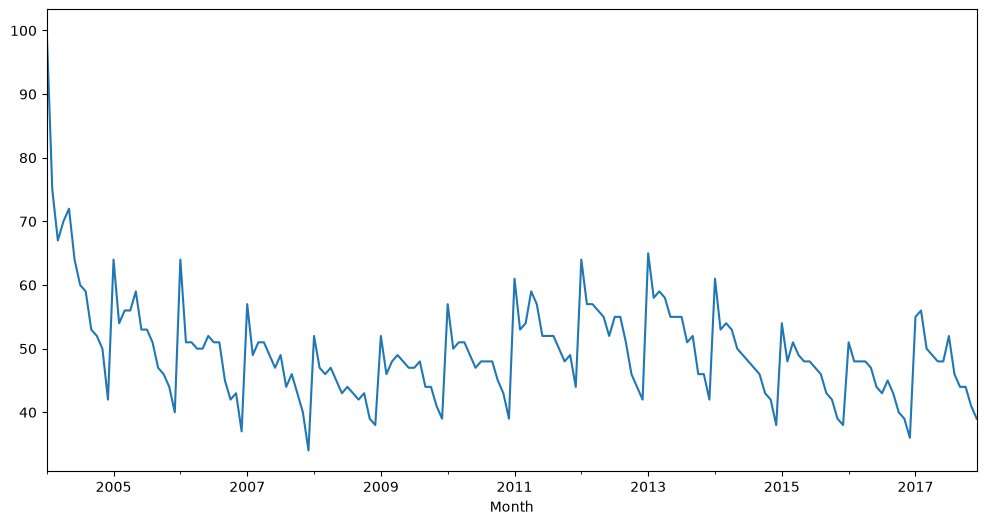

In [16]:
df.diet.plot(figsize=(12,6))

<Axes: xlabel='Month'>

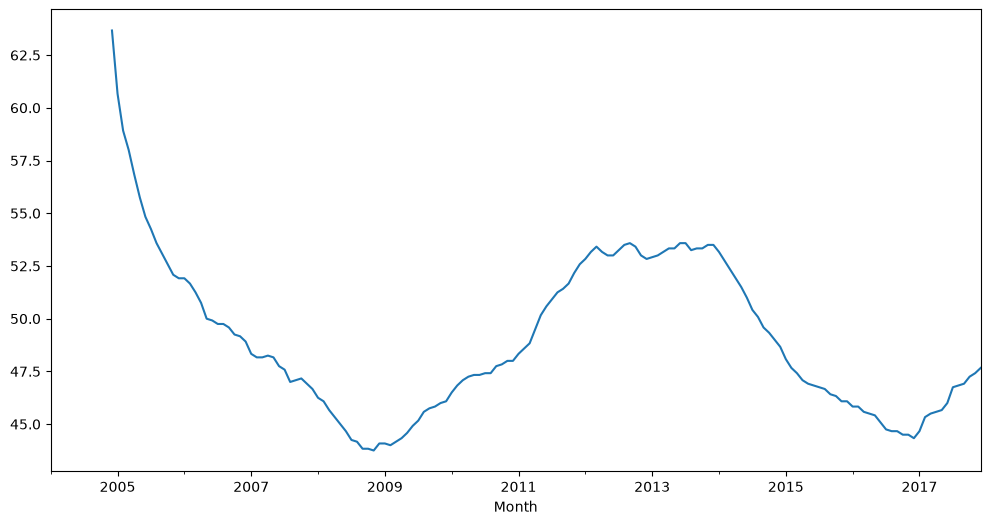

In [17]:
df.diet.rolling(12).mean().plot(figsize=(12,6))

<Axes: xlabel='Month'>

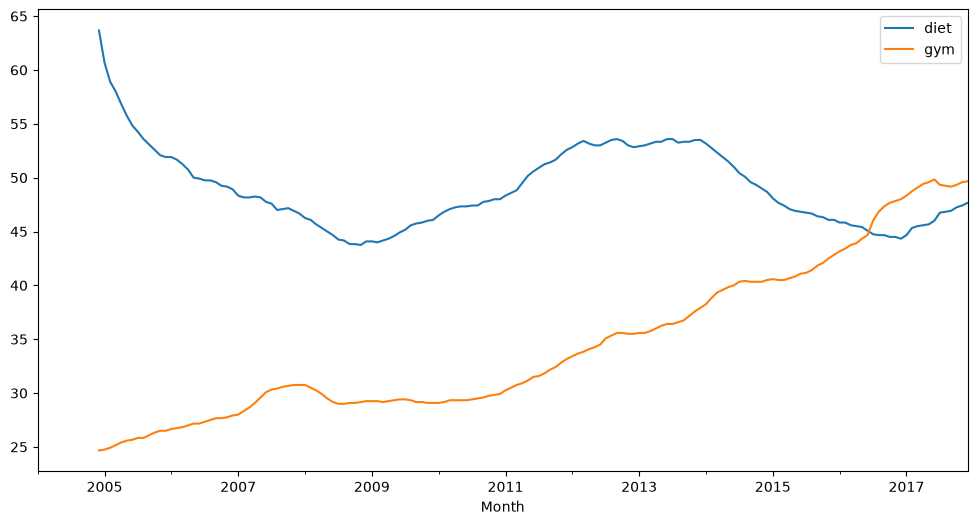

In [19]:
pd.concat([df.diet.rolling(12).mean(),df.gym.rolling(12).mean()],axis=1).plot(figsize=(12,6))

In [20]:
import datetime as dt

In [21]:
dt.datetime.now()

datetime.datetime(2026, 10, 9, 11, 48, 1, 557099)

In [22]:
dt.date(2026,12,3).month

12

In [23]:
dt.time(10,20,30,123).microsecond

123

In [24]:
dt.date(2026,12,3) + dt.timedelta(4)

datetime.date(2026, 12, 7)

In [25]:
dt.datetime.strptime("2025-12-11","%Y-%m-%d")

datetime.datetime(2025, 12, 11, 0, 0)

In [27]:
dt.datetime.strftime(dt.date(2025,4,2), '%Y-%m-%d')

'2025-04-02'

In [28]:
pd.Timestamp("2026-04-01")

Timestamp('2026-04-01 00:00:00')

In [29]:
dates = [pd.Timestamp("2026-04-01"),pd.Timestamp("2026-04-03"),pd.Timestamp("2026-04-04")]
dates

[Timestamp('2026-04-01 00:00:00'),
 Timestamp('2026-04-03 00:00:00'),
 Timestamp('2026-04-04 00:00:00')]

In [30]:
ts= pd.Series(np.random.randn(3),index=dates)
ts

2026-04-01    1.315777
2026-04-03   -1.330907
2026-04-04    0.382778
dtype: float64

In [32]:
temps = pd.read_csv("timeseries/temps.csv")

In [33]:
temps.columns

Index(['datetime', 'LA', 'NY'], dtype='str')

In [34]:
temps.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  35064 non-null  str    
 1   LA        35062 non-null  float64
 2   NY        35064 non-null  float64
dtypes: float64(2), str(1)
memory usage: 821.9 KB


In [35]:
temps.datetime = pd.to_datetime(temps.datetime)

In [37]:
temps.set_index('datetime',inplace=True)

In [38]:
temps.head()

,LA,NY
datetime,,
2013-01-01 00:00:00,11.7,-1.1
2013-01-01 01:00:00,10.7,-1.7
2013-01-01 02:00:00,9.9,-2.0
2013-01-01 03:00:00,9.3,-2.1
2013-01-01 04:00:00,8.8,-2.3


In [40]:
temps['Day_Name'] = temps.index.day_name()

In [41]:
temps.groupby("Day_Name").mean()

,LA,NY
Day_Name,,
Friday,17.595116,11.983951
Monday,17.535631,12.078546
Saturday,17.526376,11.633373
Sunday,17.590605,12.155669
Thursday,17.478010,12.163417
Tuesday,17.244737,12.243640
Wednesday,17.432396,12.219757


In [43]:
temps.loc['2014-12']

,LA,NY,Day_Name
datetime,,,
2014-12-01 00:00:00,12.1,7.2,Monday
2014-12-01 01:00:00,12.5,7.2,Monday
2014-12-01 02:00:00,12.1,7.7,Monday
2014-12-01 03:00:00,12.3,7.7,Monday
2014-12-01 04:00:00,11.6,8.0,Monday
...,...,...,...
2014-12-31 19:00:00,3.9,-1.8,Wednesday
2014-12-31 20:00:00,4.8,-2.7,Wednesday
2014-12-31 21:00:00,4.3,-2.7,Wednesday


In [44]:
start = dt.datetime(2020,11,20)
end = dt.datetime(2025,12,3)

index = pd.date_range(start,end)
index

DatetimeIndex(['2020-11-20', '2020-11-21', '2020-11-22', '2020-11-23',
               '2020-11-24', '2020-11-25', '2020-11-26', '2020-11-27',
               '2020-11-28', '2020-11-29',
               ...
               '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-27',
               '2025-11-28', '2025-11-29', '2025-11-30', '2025-12-01',
               '2025-12-02', '2025-12-03'],
              dtype='datetime64[us]', length=1840, freq='D')

In [45]:
ts

2026-04-01    1.315777
2026-04-03   -1.330907
2026-04-04    0.382778
dtype: float64

In [46]:
ts = pd.Timestamp("2016-07-22")
ts - pd.DateOffset(days = 10)

Timestamp('2016-07-12 00:00:00')

In [49]:
temps.drop(columns=['Day_Name'],inplace=True)

In [50]:
temps.resample("D").mean()

,LA,NY
datetime,,
2013-01-01,8.858333,-0.404167
2013-01-02,9.283333,3.208333
2013-01-03,10.304167,-2.425000
2013-01-04,11.512500,-2.070833
2013-01-05,11.083333,0.816667
...,...,...
2016-12-27,12.154167,10.579167
2016-12-28,14.433333,4.016667
2016-12-29,16.045833,1.312500


In [51]:
brent = pd.read_csv("timeseries/brent.csv")

In [52]:
brent.info()

<class 'pandas.DataFrame'>
RangeIndex: 5016 entries, 0 to 5015
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5016 non-null   str    
 1   Price   5016 non-null   float64
dtypes: float64(1), str(1)
memory usage: 78.5 KB


In [53]:
brent.head()

,Date,Price
0,04-Jan-00,23.95
1,05-Jan-00,23.72
2,06-Jan-00,23.55
3,07-Jan-00,23.35
4,10-Jan-00,22.77


In [55]:
brent['Date'] = pd.to_datetime(brent['Date'])

In [56]:
brent.set_index('Date',inplace=True)

In [57]:
brent.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5016 entries, 2000-01-04 to 2019-09-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   5016 non-null   float64
dtypes: float64(1)
memory usage: 78.4 KB


In [58]:
brent.head()

,Price
Date,
2000-01-04,23.95
2000-01-05,23.72
2000-01-06,23.55
2000-01-07,23.35
2000-01-10,22.77


In [60]:
brent.loc['1-1-2017':'30-1-2018',].mean()

Price    58.63649
dtype: float64

In [62]:
brent.loc['3-2015'].mean()

Price    55.885455
dtype: float64

In [63]:
brent.loc['3-2016'].mean()

Price    38.210455
dtype: float64

In [64]:
brent.loc['2016','Price'].resample('QS').mean()

Date
2016-01-01    33.842742
2016-04-01    45.566875
2016-07-01    45.801061
2016-10-01    49.052222
Freq: QS-JAN, Name: Price, dtype: float64